## ℹ️ Sobre este Notebook

Este notebook implementa **backtesting de estratégias de trading** com PySpark. Simula operações de compra/venda baseadas em modelos de Machine Learning, incluindo custos de transação, e visualiza o lucro acumulado ao longo do tempo.


# Crypto EMA Fast Movement Prediction with PySpark
This notebook demonstrates how to predict whether the trend_ema_fast (EMA fast) will go up or down for the next 5-minute candle using PySpark MLlib with logistic regression and Random Forest. We'll use a 1.22 GB dataset of 5-minute candles with technical indicators, add lagged close prices, and lagged trend_ema_fast features to improve performance. Finally, we'll backtest the Random Forest model to simulate trades, including transaction fees, and visualize the cumulative profit.

In [2]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when, lead, lag, lit
from pyspark.sql.window import Window
import uuid
import matplotlib.pyplot as plt

In [3]:
# Initialize Spark session with memory configuration for large dataset
spark = SparkSession.builder \
    .appName("CryptoEMAFastPrediction") \
    .getOrCreate()

# Show Spark version to confirm setup
print(f"Spark Version: {spark.version}")

your 131072x1 screen size is bogus. expect trouble
25/05/09 23:16:11 WARN Utils: Your hostname, msi-sobreiro resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/05/09 23:16:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/09 23:16:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 3.5.5


In [4]:
# Initialize Spark session with memory configuration for large dataset
spark = SparkSession.builder \
    .appName("CryptoEMAFastPrediction") \
    .getOrCreate()

# Show Spark version to confirm setup
print(f"Spark Version: {spark.version}")

Spark Version: 3.5.5


In [5]:
# Load the 1.22 GB CSV dataset
data_path = "./../data/btc_04h_usdt_binance.parquet"
df = spark.read.parquet(data_path)

# Show first few rows
df.show(5)

# Print schema to understand data types
df.printSchema()

25/05/09 23:16:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/05/09 23:16:21 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , open_time, open, high, low, close, volume, close_time, quote_vol, trades, taker_buy_base, taker_buy_quote, ignore, symbol, volume_adi, volume_obv, volume_cmf, volume_fi, volume_em, volume_sma_em, volume_vpt, volume_vwap, volume_mfi, volume_nvi, volatility_bbm, volatility_bbh, volatility_bbl, volatility_bbw, volatility_bbp, volatility_bbhi, volatility_bbli, volatility_kcc, volatility_kch, volatility_kcl, volatility_kcw, volatility_kcp, volatility_kchi, volatility_kcli, volatility_dcl, volatility_dch, volatility_dcm, volatility_dcw, volatility_dcp, volatility_atr, volatility_ui, trend_macd, trend_macd_signal, trend_macd_diff, trend_sma_fast, trend_sma_slow, trend_ema_fast, trend_ema_slow, trend_vortex_ind_pos

+---+--------------------+-------+-------+-------+-------+--------+--------------------+--------------+------+--------------+---------------+------+-------+--------------------+-------------------+----------+---------+------------------+-------------+--------------------+-----------+----------+----------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+-----------------+-----------------+--------------+-------------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+---------+---------+-------------+--------------+-------------------+-------------------+----------------+------------------+---------+---------+-------------+---------

In [6]:
# Define feature columns (technical indicators and other metrics)
features = [
    'open', 'high', 'low', 'volume', 'quote_vol', 'trades', 'taker_buy_base', 
    'taker_buy_quote', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 
    'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 
    'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl', 
    'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 
    'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 
    'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 
    'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 
    'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 
    'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 
    'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 
    'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo', 
    'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 
    'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 
    'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_cci', 
    'trend_visual_ichimoku_a', 'trend_visual_ichimoku_b', 'trend_aroon_up', 
    'trend_aroon_down', 'trend_aroon_ind', 'momentum_rsi', 'momentum_stoch_rsi', 
    'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 
    'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_wr', 
    'momentum_ao', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_signal', 
    'momentum_ppo_hist', 'momentum_kama', 'others_dr', 'others_dlr', 'others_cr', 
    'morningstar', 'hammer', 'piercing', '3soldiers', 'engulfing', 'sma200', 
    'sma50', 'ema200', 'ema50', 'slope', 'slope_obv', 'slope_rsi'
]

### Example of Lagged Features

Assume the original dataset has the following columns:

| open_time       | close  | trend_ema_fast |
|-----------------|--------|----------------|
| 2025-05-09 00:00 | 100.0  | 98.0           |
| 2025-05-09 00:05 | 101.0  | 99.0           |
| 2025-05-09 00:10 | 102.0  | 100.0          |
| 2025-05-09 00:15 | 103.0  | 101.0          |
| 2025-05-09 00:20 | 104.0  | 102.0          |
| 2025-05-09 00:25 | 105.0  | 103.0          |

After adding lagged features for the previous 5 candles, the DataFrame would look like this:

| open_time       | close  | trend_ema_fast | close_lag_1 | close_lag_2 | close_lag_3 | close_lag_4 | close_lag_5 | ema_fast_lag_1 | ema_fast_lag_2 | ema_fast_lag_3 | ema_fast_lag_4 | ema_fast_lag_5 |
|-----------------|--------|----------------|-------------|-------------|-------------|-------------|-------------|----------------|----------------|----------------|----------------|----------------|
| 2025-05-09 00:00 | 100.0  | 98.0           | null        | null        | null        | null        | null        | null           | null           | null           | null           | null           |
| 2025-05-09 00:05 | 101.0  | 99.0           | 100.0       | null        | null        | null        | null        | 98.0           | null           | null           | null           | null           |
| 2025-05-09 00:10 | 102.0  | 100.0          | 101.0       | 100.0       | null        | null        | null        | 99.0           | 98.0           | null           | null           | null           |
| 2025-05-09 00:15 | 103.0  | 101.0          | 102.0       | 101.0       | 100.0       | null        | null        | 100.0          | 99.0           | 98.0           | null           | null           |
| 2025-05-09 00:20 | 104.0  | 102.0          | 103.0       | 102.0       | 101.0       | 100.0       | null        | 101.0          | 100.0          | 99.0           | 98.0           | null           |
| 2025-05-09 00:25 | 105.0  | 103.0          | 104.0       | 103.0       | 102.0       | 101.0       | 100.0       | 102.0          | 101.0          | 100.0          | 99.0           | 98.0           |

This transformation allows the model to use historical data as features for predicting future trends.

In [7]:
# Create lagged features for the previous 5 candles' close prices and trend_ema_fast
window_spec = Window.orderBy("open_time")

# Add lagged close prices (lag 1 to 5)
for i in range(1, 6):
    lag_col_name = f"close_lag_{i}"
    df = df.withColumn(lag_col_name, lag(col("close").cast("double"), i).over(window_spec))
    features.append(lag_col_name)

# Add lagged trend_ema_fast values (lag 1 to 5)
for i in range(1, 6):
    lag_col_name = f"ema_fast_lag_{i}"
    df = df.withColumn(lag_col_name, lag(col("trend_ema_fast").cast("double"), i).over(window_spec))
    features.append(lag_col_name)

# Create target variable: 1 if next candle's trend_ema_fast > current trend_ema_fast, else 0
df = df.withColumn("next_ema_fast", lead(col("trend_ema_fast").cast("double"), 1).over(window_spec))
df = df.withColumn("label", when(col("next_ema_fast") > col("trend_ema_fast"), 1).otherwise(0))

# Drop rows with null values in features or label
df = df.dropna(subset=features + ["label"])

# Cast features to double for ML
for feature in features:
    df = df.withColumn(feature, col(feature).cast("double"))

# Show sample of processed data
df.select("trend_ema_fast", "ema_fast_lag_1", "ema_fast_lag_2", "next_ema_fast", "label").show(5)

25/05/09 23:16:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:16:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:16:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:16:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:16:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:16:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 2

+-----------------+-----------------+------------------+------------------+-----+
|   trend_ema_fast|   ema_fast_lag_1|    ema_fast_lag_2|     next_ema_fast|label|
+-----------------+-----------------+------------------+------------------+-----+
|4336.059236627935|4333.099097833014|4331.4880247117435| 4336.865507915945|    1|
|4336.865507915945|4336.059236627935| 4333.099097833014|   4339.2461990058|    1|
|  4339.2461990058|4336.865507915945| 4336.059236627935| 4338.869860697216|    0|
|4338.869860697216|  4339.2461990058| 4336.865507915945| 4338.551420589952|    0|
|4338.551420589952|4338.869860697216|   4339.2461990058|4338.2019712684205|    0|
+-----------------+-----------------+------------------+------------------+-----+
only showing top 5 rows



In [8]:
# Split data into training (80%) and test (20%) sets
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# Cache datasets for faster processing
train_df.cache()
test_df.cache()

# Print dataset sizes
print(f"Training set size: {train_df.count()} rows")
print(f"Test set size: {test_df.count()} rows")

25/05/09 23:17:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:17:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:17:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:17:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:17:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:17:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 2

Training set size: 625853 rows


25/05/09 23:20:12 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , open_time, open, high, low, close, volume, close_time, quote_vol, trades, taker_buy_base, taker_buy_quote, ignore, symbol, volume_adi, volume_obv, volume_cmf, volume_fi, volume_em, volume_sma_em, volume_vpt, volume_vwap, volume_mfi, volume_nvi, volatility_bbm, volatility_bbh, volatility_bbl, volatility_bbw, volatility_bbp, volatility_bbhi, volatility_bbli, volatility_kcc, volatility_kch, volatility_kcl, volatility_kcw, volatility_kcp, volatility_kchi, volatility_kcli, volatility_dcl, volatility_dch, volatility_dcm, volatility_dcw, volatility_dcp, volatility_atr, volatility_ui, trend_macd, trend_macd_signal, trend_macd_diff, trend_sma_fast, trend_sma_slow, trend_ema_fast, trend_ema_slow, trend_vortex_ind_pos, trend_vortex_ind_neg, trend_vortex_ind_diff, trend_trix, trend_mass_index, trend_dpo, trend_kst, trend_kst_sig, trend_kst_diff, trend_ichimoku_conv, trend_ichimoku_base, trend_ichimoku_a,

Test set size: 156204 rows


In [9]:
# Create feature vector
assembler = VectorAssembler(inputCols=features, outputCol="features")

# Scale features to normalize data
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", 
                       withStd=True, withMean=True)

In [10]:
# Initialize models
# Logistic Regression
lr = LogisticRegression(featuresCol="scaled_features", labelCol="label", 
                       maxIter=100, regParam=0.1)

# Random Forest
rf = RandomForestClassifier(featuresCol="scaled_features", labelCol="label", 
                           numTrees=100, maxDepth=10, seed=42)

In [11]:
# Create pipelines for both models
lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
rf_pipeline = Pipeline(stages=[assembler, scaler, rf])

# Train models
print("Training Logistic Regression...")
lr_model = lr_pipeline.fit(train_df)

print("Training Random Forest...")
rf_model = rf_pipeline.fit(train_df)

Training Logistic Regression...


Training Random Forest...


25/05/09 23:24:42 WARN DAGScheduler: Broadcasting large task binary with size 1222.2 KiB
25/05/09 23:25:21 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/05/09 23:26:18 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
25/05/09 23:27:26 WARN DAGScheduler: Broadcasting large task binary with size 1122.0 KiB
25/05/09 23:27:28 WARN DAGScheduler: Broadcasting large task binary with size 7.8 MiB
25/05/09 23:28:27 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/05/09 23:28:30 WARN DAGScheduler: Broadcasting large task binary with size 14.8 MiB
25/05/09 23:29:47 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB


In [12]:
# Make predictions on test set
lr_predictions = lr_model.transform(test_df)
rf_predictions = rf_model.transform(test_df)

# Show sample predictions
lr_predictions.select("label", "prediction", "probability").show(5)
rf_predictions.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       0.0|[0.85374610480821...|
|    0|       0.0|[0.79985829360989...|
|    1|       0.0|[0.61425931001704...|
|    0|       0.0|[0.57180774901500...|
|    0|       0.0|[0.70744497890830...|
+-----+----------+--------------------+
only showing top 5 rows



25/05/09 23:29:55 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       0.0|[0.87278565072855...|
|    0|       0.0|[0.77863149782057...|
|    1|       1.0|[0.48100873064294...|
|    0|       0.0|[0.55286733705927...|
|    0|       0.0|[0.76770525813898...|
+-----+----------+--------------------+
only showing top 5 rows



In [13]:
# Evaluate models using Area Under ROC Curve (AUC) and Confusion Matrix
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# AUC Evaluator
evaluator_roc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

# Multi-class evaluator for precision, recall, and F1-score
evaluator_multi = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Evaluate Logistic Regression
lr_auc = evaluator_roc.evaluate(lr_predictions)
lr_precision = evaluator_multi.evaluate(lr_predictions, {evaluator_multi.metricName: "weightedPrecision"})
lr_recall = evaluator_multi.evaluate(lr_predictions, {evaluator_multi.metricName: "weightedRecall"})
lr_f1 = evaluator_multi.evaluate(lr_predictions, {evaluator_multi.metricName: "f1"})

# Evaluate Random Forest
rf_auc = evaluator_roc.evaluate(rf_predictions)
rf_precision = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "weightedPrecision"})
rf_recall = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "weightedRecall"})
rf_f1 = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "f1"})

# Compute Confusion Matrix for Logistic Regression
lr_confusion = lr_predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")
print("Logistic Regression Confusion Matrix:")
lr_confusion.show()

# Compute Confusion Matrix for Random Forest
rf_confusion = rf_predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")
print("Random Forest Confusion Matrix:")
rf_confusion.show()

# Print evaluation results
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")
print(f"Logistic Regression Recall: {lr_recall:.4f}")
print(f"Logistic Regression F1-Score: {lr_f1:.4f}")
print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1-Score: {rf_f1:.4f}")

25/05/09 23:30:03 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB
25/05/09 23:30:12 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB
25/05/09 23:30:19 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB
25/05/09 23:30:27 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB


Logistic Regression Confusion Matrix:


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|59603|
|    0|       1.0|16476|
|    1|       0.0|15458|
|    1|       1.0|64667|
+-----+----------+-----+

Random Forest Confusion Matrix:


25/05/09 23:30:37 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|60475|
|    0|       1.0|15604|
|    1|       0.0|15078|
|    1|       1.0|65047|
+-----+----------+-----+

Logistic Regression AUC: 0.8818
Logistic Regression Precision: 0.7955
Logistic Regression Recall: 0.7956
Logistic Regression F1-Score: 0.7955
Random Forest AUC: 0.8879
Random Forest Precision: 0.8036
Random Forest Recall: 0.8036
Random Forest F1-Score: 0.8036


Sample Backtest Results:


25/05/09 23:44:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:44:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:44:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:44:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:44:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:44:38 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB


+--------------------+-----------------+------------------+----------+------------+--------------------+-------------+--------------------+--------------------+
|           open_time|   trend_ema_fast|     next_ema_fast|prediction|trade_action|     ema_fast_change|trade_outcome|        trade_profit|   cumulative_profit|
+--------------------+-----------------+------------------+----------+------------+--------------------+-------------+--------------------+--------------------+
|2017-08-17 22:50:...|  4339.2461990058| 4338.869860697216|       1.0|         buy|-8.67289596682794...|         loss|-0.09672895966827942|-0.09672895966827942|
|2017-08-17 23:10:...|4335.910898765587|4336.1338374170355|       0.0|        sell|5.141679722055003E-5|         loss| 0.04141679722055003|-0.05531216244772939|
|2017-08-17 23:35:...|4334.241662883751| 4333.319868593943|       0.0|        sell|-2.12677178963369...|       profit| 0.09000000000000001| 0.03468783755227062|
|2017-08-18 00:20:...|4306.6034465

25/05/09 23:44:49 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
25/05/09 23:45:04 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
25/05/09 23:45:18 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB
25/05/09 23:45:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Backtest Summary:
Total Trades: 128762
Winning Trades: 98080
Win Rate: 0.7617
Final Balance: $18397.60
Total Profit/Loss: $8397.60


25/05/09 23:45:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:45:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:45:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:45:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/05/09 23:45:25 WARN DAGScheduler: Broadcasting large task binary with size 8.3 MiB


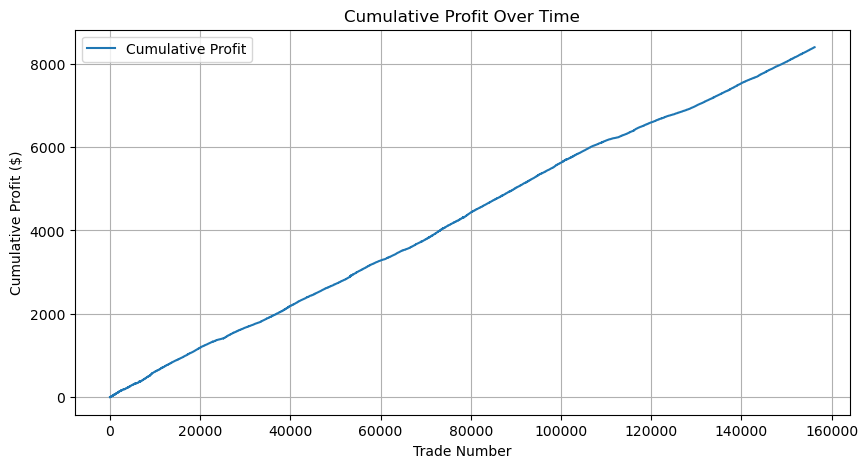

In [22]:
# Backtest the Random Forest model on the test dataset
from pyspark.sql.functions import col, when, lag, lead, lit, sum as pyspark_sum
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# Define backtest parameters
take_profit_threshold = 0.0001  # 0.01% movement in trend_ema_fast to take profit
initial_balance = 10000.0  # Starting balance in USD
position_size = 0.1  # Risk 10% of balance per trade
transaction_fee = 0.00001  # 0.001% fee per trade

# Add columns to track trade outcomes
window_spec = Window.orderBy("open_time").rowsBetween(Window.unboundedPreceding, 0)

# Get the actual movement of trend_ema_fast (already in next_ema_fast)
# Add a column to determine trade direction based on prediction
rf_predictions = rf_predictions.withColumn(
    "trade_action",
    when(col("prediction") == 1, "buy").otherwise("sell")
)

# Calculate the percentage change in trend_ema_fast
rf_predictions = rf_predictions.withColumn(
    "ema_fast_change",
    (col("next_ema_fast") - col("trend_ema_fast")) / col("trend_ema_fast")
)

# Determine trade outcome
# For a buy: take profit if ema_fast increases by 0.5%, stop loss if it decreases
# For a sell: take profit if ema_fast decreases by 0.5%, stop loss if it increases
rf_predictions = rf_predictions.withColumn(
    "trade_outcome",
    when(
        (col("trade_action") == "buy") & (col("ema_fast_change") >= take_profit_threshold),
        "profit"
    ).when(
        (col("trade_action") == "buy") & (col("ema_fast_change") < 0),
        "loss"
    ).when(
        (col("trade_action") == "sell") & (col("ema_fast_change") <= -take_profit_threshold),
        "profit"
    ).when(
        (col("trade_action") == "sell") & (col("ema_fast_change") > 0),
        "loss"
    ).otherwise("no_trade")  # If the movement doesn't hit TP or SL, no trade is closed
)

# Calculate profit/loss for each trade, including transaction fees
# Assume profit/loss is proportional to the position size and the percentage change
rf_predictions = rf_predictions.withColumn(
    "trade_profit",
    when(col("trade_outcome") == "profit", 
         initial_balance * position_size * take_profit_threshold - initial_balance * position_size * transaction_fee)
    .when(col("trade_outcome") == "loss", 
          initial_balance * position_size * col("ema_fast_change") - initial_balance * position_size * transaction_fee)
    .otherwise(0.0)
)

# Compute cumulative profit/loss using sum over the window
rf_predictions = rf_predictions.withColumn(
    "cumulative_profit",
    pyspark_sum(col("trade_profit")).over(window_spec)
)

# Show sample of backtest results
print("Sample Backtest Results:")
rf_predictions.select(
    "open_time", "trend_ema_fast", "next_ema_fast", "prediction", "trade_action",
    "ema_fast_change", "trade_outcome", "trade_profit", "cumulative_profit"
).show(10)

# Compute backtest summary
total_trades = rf_predictions.filter(col("trade_outcome").isin("profit", "loss")).count()
winning_trades = rf_predictions.filter(col("trade_outcome") == "profit").count()
final_balance = initial_balance + rf_predictions.select("trade_profit").agg({"trade_profit": "sum"}).collect()[0][0]

# Print backtest summary
print("Backtest Summary:")
print(f"Total Trades: {total_trades}")
print(f"Winning Trades: {winning_trades}")
print(f"Win Rate: {winning_trades / total_trades:.4f}" if total_trades > 0 else "Win Rate: N/A")
print(f"Final Balance: ${final_balance:.2f}")
print(f"Total Profit/Loss: ${final_balance - initial_balance:.2f}")

# Visualize cumulative profit over time
profits = rf_predictions.select("cumulative_profit").collect()
profits_list = [row["cumulative_profit"] for row in profits]
plt.figure(figsize=(10, 5))
plt.plot(profits_list, label="Cumulative Profit")
plt.title("Cumulative Profit Over Time")
plt.xlabel("Trade Number")
plt.ylabel("Cumulative Profit ($)")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
# Save models for future use
#lr_model.save(f"lr_model_{uuid.uuid4()}")
#rf_model.save(f"rf_model_{uuid.uuid4()}")

# Stop Spark session to free resources
spark.stop()